<a href="https://colab.research.google.com/github/modouseck/Python-Machine-Learning/blob/master/cheick_point_classification_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Infos générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country_number                   1059 non-null   int64  
 1   country_code                     1059 non-null   object 
 2   country                          1059 non-null   object 
 3   year                             1059 non-null   int64  
 4   systemic_crisis                  1059 non-null   int64  
 5   exch_usd                         1059 non-null   float64
 6   domestic_debt_in_default         1059 non-null   int64  
 7   sovereign_external_debt_default  1059 non-null   int64  
 8   gdp_weighted_default             1059 non-null   float64
 9   inflation_annual_cpi             1059 non-null   float64
 10  independence                     1059 non-null   int64  
 11  currency_crises                  1059 non-null   int64  
 12  i

/tmp/ipython-input-24-4213690731.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


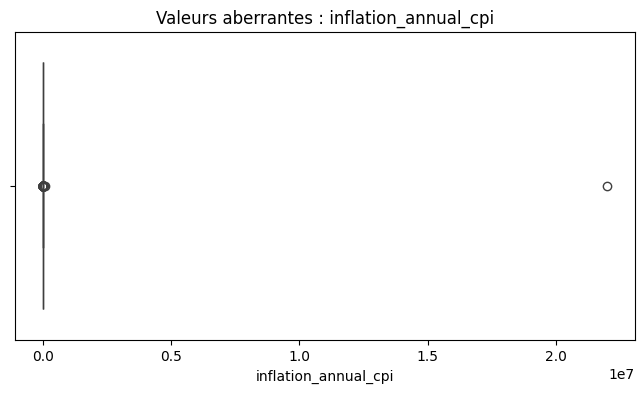


--- ÉVALUATION DU MODÈLE ---
Accuracy : 0.9947643979057592
Confusion Matrix :
 [[178   0]
 [  1  12]]
Classification Report :
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       178
           1       1.00      0.92      0.96        13

    accuracy                           0.99       191
   macro avg       1.00      0.96      0.98       191
weighted avg       0.99      0.99      0.99       191



In [24]:
# ---------------------- IMPORTATIONS ----------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---------------------- CHARGEMENT DU JEU DE DONNÉES ----------------------
df= pd.read_csv('/content/African_crises_dataset.csv')



# ---------------------- INFO GÉNÉRALES ----------------------
print("\nInfos générales :")
print(df.info())
print("\nStatistiques descriptives :")
print(df.describe(include="all"))
print("\nColonnes :", df.columns)

# ---------------------- PROFILING ----------------------
#profile = ProfileReport(df, title="Profiling - Crises Africaines", explorative=True)
#profile.to_file("rapport_profiling.html")  # Génère un rapport HTML

# ---------------------- VALEURS MANQUANTES ----------------------
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())
df.fillna(method='ffill', inplace=True)

# ---------------------- DOUBLONS ----------------------
print("\nNombre de doublons :", df.duplicated().sum())
df.drop_duplicates(inplace=True)

# ---------------------- VALEURS ABERRANTES (exemple sur inflation) ----------------------
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['inflation_annual_cpi'])
plt.title("Valeurs aberrantes : inflation_annual_cpi")
plt.show()

# Suppression optionnelle des valeurs extrêmes
Q1 = df['inflation_annual_cpi'].quantile(0.25)
Q3 = df['inflation_annual_cpi'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['inflation_annual_cpi'] >= Q1 - 1.5 * IQR) & (df['inflation_annual_cpi'] <= Q3 + 1.5 * IQR)]

# ---------------------- ENCODAGE DES VARIABLES CATÉGORIELLES ----------------------
df_encoded = pd.get_dummies(df, drop_first=True)

# ---------------------- SÉPARATION FEATURES / CIBLE ----------------------
X = df_encoded.drop(columns=['systemic_crisis'])
y = df_encoded['systemic_crisis']

# ---------------------- TRAIN / TEST SPLIT ----------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------- MODÈLE ML ----------------------
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# ---------------------- ÉVALUATION DU MODÈLE ----------------------
y_pred = model.predict(X_test)
print("\n--- ÉVALUATION DU MODÈLE ---")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))
print("Classification Report :\n", classification_report(y_test, y_pred))



In [17]:
df.describe()

,country_number,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises
count,951.000000,951.000000,951.000000,951.000000,951.000000,951.000000,951.000000,951.000000,951.000000,951.000000,951.00000
mean,35.914826,1967.903260,0.064143,46.525202,0.022082,0.127234,0.006404,6.111191,0.786540,0.092534,0.04837
std,23.031651,33.192566,0.245136,116.570846,0.147028,0.333411,0.044180,6.649023,0.409965,0.297104,0.21466
min,1.000000,1860.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-11.806768,0.000000,0.000000,0.00000
25%,15.000000,1952.000000,0.000000,0.198650,0.000000,0.000000,0.000000,1.950683,1.000000,0.000000,0.00000
50%,38.000000,1972.000000,0.000000,1.191000,0.000000,0.000000,0.000000,5.139000,1.000000,0.000000,0.00000
75%,56.000000,1993.500000,0.000000,8.675850,0.000000,0.000000,0.000000,9.881625,1.000000,0.000000,0.00000
max,70.000000,2014.000000,1.000000,744.306139,1.000000,1.000000,0.400000,25.956000,1.000000,2.000000,1.00000


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 951 entries, 0 to 1058
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country_number                   951 non-null    int64  
 1   country_code                     951 non-null    object 
 2   country                          951 non-null    object 
 3   year                             951 non-null    int64  
 4   systemic_crisis                  951 non-null    int64  
 5   exch_usd                         951 non-null    float64
 6   domestic_debt_in_default         951 non-null    int64  
 7   sovereign_external_debt_default  951 non-null    int64  
 8   gdp_weighted_default             951 non-null    float64
 9   inflation_annual_cpi             951 non-null    float64
 10  independence                     951 non-null    int64  
 11  currency_crises                  951 non-null    int64  
 12  inflation_crises          